# Non-reversible vs reversible anchored Langevin — a self-contained walk-through

**Question.** Does the non-reversible anchored Langevin sampler (block skew-symmetric
$J_s$, $\alpha=1$) reach good predictions faster than the reversible one ($\alpha=0$) on a
constrained Bayesian logistic regression whose target has a **non-differentiable** LASSO
term?

**Answer (in the figures below).** Yes, by a wide margin: with the design described in
section 1, after 100 iterations the non-reversible chain is at $\approx0.72$ test accuracy
versus $\approx0.56$ for the reversible one on the $L_1$ ball ($0.66$ vs $0.55$ at iteration 60
on the unit ball); both end at the same plateau by iteration 1000. The margin survives held-out random
seeds ($t\approx29$ on both constraint sets).

These numbers are for the full setting ($R=100$ chains, 1000 iterations, four held-out
seeds), which takes about a minute on one core. Setting the environment variable
`NRAL_QUICK=1` before starting the kernel runs $R=20$ chains for 300 iterations with one
held-out seed in a few seconds; the numbers then differ.

**How to read this notebook.** Every ingredient is written out in its own cell:
the data (1), the target $U=f+g$ (2), the anchor $U_0=f+g_0$ and $a(w)=e^{U-U_0}$ (3),
the constraint sets and $J_s$ (4), the update rule (5), the runs (6), the figures (7),
the numbers (8) and the explanation (9). Nothing is imported from the repository — the
constraint sets, their uniform samplers and the Euclidean projections are written out in
section 4 — so the notebook runs anywhere (Colab included) with numpy, scipy,
scikit-learn, pandas and matplotlib.

Notation: $d=9$ parameters, $w=(w_0,w_1,\dots,w_8)$ with $w_0$ the intercept;
$x_j\in\mathbb R^9$ has a leading 1; $R$ replicate chains run in parallel as the rows of a
$(R,d)$ array.

In [1]:
import os, sys, time, hashlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy.special import expit
from sklearn.model_selection import train_test_split

QUICK           = os.environ.get("NRAL_QUICK", "0") == "1"
R               = 20 if QUICK else 100        # replicate chains
N_ITERATIONS    = 300 if QUICK else 1000
CHECKPOINT      = 10                          # accuracy is recorded every CHECKPOINT iterations
LAMBDA_LASSO    = 2.0                         # strength of the non-differentiable g
DELTA           = 0.02                        # smoothing of g inside the anchor U_0
SIGMA_INTERCEPT = 5.0                         # sd of the Gaussian prior on the intercept w_0
EPSILON         = 0.2                         # smoothing of the L1 constraint (soft-sign width)
HELD_OUT        = (101,) if QUICK else (101, 202, 303, 404)   # extra sampler seeds for confirmation
OUT             = "results_beat"; os.makedirs(OUT, exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("QUICK MODE" if QUICK else "FULL", f"| R = {R}, {N_ITERATIONS} iterations")

FULL | R = 100, 1000 iterations


## 1. Data — unstandardised covariates, with the slow direction where $J$ can reach it

Synthetic logistic regression, 2000 observations (80% train / 20% test), intercept plus 8
slopes. $J_s$ (section 4) acts on the coordinate triples $(0,1,2),(3,4,5),(6,7,8)$. The first
triple is the intercept plus slopes 1, 2 (kept isotropic and weak, $\beta_1=\beta_2=b_1$);
the two full slope triples $(3,4,5)$ and $(6,7,8)$ carry the structured design below.

Inside each of the two full triples the covariance is

$$\Sigma_I = v_{\rm axis}\,q_1q_1^\top + v_{\rm fast}\,q_2q_2^\top + v_{\rm slow}\,q_3q_3^\top,\qquad
q_1=\tfrac{(1,1,1)}{\sqrt3},\; q_2=\tfrac{(0,1,-1)}{\sqrt2},\; q_3=\tfrac{(2,-1,-1)}{\sqrt6},$$

with $\beta_I=(b,e,e)$, $b>e>0$. Three facts about this choice (section 9 explains why they matter):

* $q_1$ is the axis about which the $L_1$ block rotation turns (the soft-sign of a
  positive $\beta_I$ is $\propto(1,1,1)$), so $q_2,q_3$ span the plane that $J$ rotates;
* $q_2\cdot\beta_I=0$: the fast direction carries no signal, so its large variance does
  not saturate the logits;
* $q_3\cdot\beta_I=\tfrac{2(b-e)}{\sqrt6}\neq0$ and $v_{\rm slow}\ll v_{\rm fast}$: of the two
  directions in the rotated plane, $q_3$ is the slow one (curvature of $U_0$ at the mode
  $\approx340$ along $q_3$ vs $\approx14{,}000$ along $q_2$, ratio $\kappa\approx40$) and it
  carries signal. The axis direction $q_1$ ($v_{\rm axis}=1$) is slower still, but no block
  rotation can act on it, so both chains share that cost.

Writing $\eta$ for the step size (section 5), $a\approx0.95$ for the anchor scale
(section 3) and $\lambda_{\rm fast},\lambda_{\rm slow}$ for the curvatures of $U_0$ along
$q_2,q_3$: the reversible chain needs $\sim1/(\eta a\lambda_{\rm slow})$ iterations to relax
along $q_3$, the non-reversible one $\sim2/(\eta a\lambda_{\rm fast})$. That is the whole effect.

For the unit-ball runs the $L_1$ design would put $\beta_{\rm true}$ outside $K$
($\|\beta\|_2=2.22$), so $\beta$ is halved ($\|\beta\|_2=0.78$) and $v_{\rm axis}$, $v_{\rm fast}$
and the block-1 variance are quadrupled while $v_{\rm slow}$ is only doubled ($2\to4$). The
ball design is therefore *more* anisotropic ($v_{\rm fast}/v_{\rm slow}=64$ vs $32$), its
logits are smaller (Bayes ceiling $0.74$ vs $0.82$) and the curvature of $U_0$ is about five
times larger — hence the smaller $\eta$ in section 6.

In [2]:
def make_data(v_axis, v_fast, v_slow, b, e, b1, block1_variance, n_total=2000, data_seed=2026, split_seed=2027):
    q1 = np.ones(3) / np.sqrt(3.0); q2 = np.array([0.0, 1.0, -1.0]) / np.sqrt(2.0); q3 = np.array([2.0, -1.0, -1.0]) / np.sqrt(6.0)
    block = v_axis * np.outer(q1, q1) + v_fast * np.outer(q2, q2) + v_slow * np.outer(q3, q3)
    Sigma = block1_variance * np.eye(8)                      # slopes 1,2 (with the intercept in block 1): isotropic
    Sigma[2:5, 2:5] = block; Sigma[5:8, 5:8] = block         # slopes 3-5 and 6-8: the structured triples
    beta = np.array([0.0, b1, b1, b, e, e, b, e, e])         # intercept first
    rng = np.random.default_rng(data_seed)
    Z = rng.multivariate_normal(np.zeros(8), Sigma, size=n_total)   # same call as anchored_lasso.make_scaled_dataset: identical data set
    X = np.hstack([np.ones((n_total, 1)), Z])                # column 0 is the intercept
    y = (rng.uniform(size=n_total) <= expit(X @ beta)).astype(float)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=split_seed, stratify=y, shuffle=True)
    return dict(X_train=np.ascontiguousarray(X_tr), y_train=y_tr, X_test=np.ascontiguousarray(X_te), y_test=y_te, beta=beta, Sigma=Sigma)

DATA = {
    "l1":   make_data(v_axis=1.0, v_fast=64.0,  v_slow=2.0, b=1.5, e=0.25,  b1=0.3,  block1_variance=1.0),
    "ball": make_data(v_axis=4.0, v_fast=256.0, v_slow=4.0, b=0.5, e=0.125, b1=0.15, block1_variance=4.0),
}
for tag, D in DATA.items():
    z = D["X_test"] @ D["beta"]
    ceiling = np.mean(np.maximum(expit(z), 1 - expit(z)))      # accuracy of the TRUE beta = the Bayes ceiling
    print(f"{tag:5s} n_train {len(D['y_train'])}, n_test {len(D['y_test'])}, positives {D['y_train'].mean():.3f}, "
          f"|beta|_1 {np.abs(D['beta']).sum():.2f}, |beta|_2 {np.linalg.norm(D['beta']):.2f}, Bayes ceiling {ceiling:.4f}")
    print("      feature sd:", np.round(D["X_train"][:, 1:].std(axis=0), 2), " <- unequal scales inside each triple")

l1    n_train 1600, n_test 400, positives 0.514, |beta|_1 4.60, |beta|_2 2.22, Bayes ceiling 0.8156
      feature sd: [0.97 0.98 1.26 5.81 5.81 1.3  5.83 5.83]  <- unequal scales inside each triple
ball  n_train 1600, n_test 400, positives 0.506, |beta|_1 1.80, |beta|_2 0.78, Bayes ceiling 0.7366
      feature sd: [ 1.94  2.02  2.   11.52 11.44  2.04 11.62 11.55]  <- unequal scales inside each triple


## 2. The target $U=f+g$

$$U(w)=\underbrace{\sum_{j=1}^{n}\Bigl[\log\bigl(1+e^{x_j^\top w}\bigr)-y_j\,x_j^\top w\Bigr]+\frac{w_0^2}{2\sigma^2}}_{f(w)\ \text{— differentiable}}
\;+\;\underbrace{\lambda_{\rm lasso}\sum_{j=1}^{8}|w_j|}_{g(w)\ \text{— NOT differentiable at } w_j=0}$$

Here $n=1600$ is the training set, $\sigma=5$ (`SIGMA_INTERCEPT`), $\lambda_{\rm lasso}=2$
(`LAMBDA_LASSO`), and $K\subset\mathbb R^9$ is the constraint set of section 4 (a ball), so the
posterior we want to sample is $\pi(w)\propto e^{-U(w)}\mathbf 1_K(w)$. $f$ is the logistic
negative log-likelihood plus a weak Gaussian prior on the intercept; $g$ is the LASSO
penalty on the slopes (the intercept is not penalised). Because $\nabla g$ does not exist on
the coordinate hyperplanes, $\nabla U$ cannot be used in a Langevin drift — that is what the
anchor in section 3 is for.

In [3]:
def f(w, X, y):
    """Differentiable part: logistic negative log-likelihood + Gaussian prior on the intercept.  w: (R, d)."""
    z = X @ w.T                                                   # (n, R) linear predictors
    return (np.logaddexp(0.0, z) - y[:, None] * z).sum(axis=0) + w[:, 0] ** 2 / (2.0 * SIGMA_INTERCEPT ** 2)

def g(w):
    """NON-differentiable part: LASSO penalty on the slopes w_1..w_8 (the intercept w_0 is not penalised)."""
    return LAMBDA_LASSO * np.abs(w[:, 1:]).sum(axis=1)

def U(w, X, y):
    """The target potential: pi(w) is proportional to exp(-U(w)) on K."""
    return f(w, X, y) + g(w)

## 3. The anchor $U_0=f+g_0$ and the state-dependent scale $a(w)$

Replace $|w_j|$ by the smooth $\sqrt{w_j^2+\delta^2}$:

$$g_0(w)=\lambda_{\rm lasso}\sum_{j=1}^{8}\sqrt{w_j^2+\delta^2},\qquad U_0=f+g_0,\qquad
a(w)=e^{U(w)-U_0(w)}=e^{\,g(w)-g_0(w)}\in\bigl[e^{-8\lambda_{\rm lasso}\delta},\,1\bigr].$$

$U_0$ is $C^\infty$, so its gradient exists everywhere — but $e^{-U_0}$ is the wrong target.
The anchored diffusion fixes this by rescaling both drift and noise by $a(w)$, which is why
$a$ multiplies every term of the update in section 5:
$dw=-a(w)\nabla U_0(w)\,dt+\sqrt{2a(w)}\,dB_t$ has invariant density
$\propto e^{-U_0}/a=e^{-U}$ — the *true* non-differentiable target — even though only $U_0$ is
ever differentiated. The cost of a large $\lambda_{\rm lasso}\delta$ is a small $a$, i.e. a
slow clock, so $\delta$ is kept small.

In [4]:
def g0(w):
    """Smooth stand-in for g: lambda * sum_j sqrt(w_j^2 + delta^2) over the slopes."""
    return LAMBDA_LASSO * np.sqrt(w[:, 1:] ** 2 + DELTA ** 2).sum(axis=1)

def U0(w, X, y):
    """The anchor: f + g_0, smooth everywhere."""
    return f(w, X, y) + g0(w)

def grad_U0(w, X, y):
    """EXACT gradient of U_0 (nothing is subsampled).  w: (R, d) -> (R, d)."""
    residual = expit(X @ w.T) - y[:, None]                        # (n, R) = p_j(w) - y_j
    grad = residual.T @ X                                         # (R, d) gradient of the log-likelihood part
    grad[:, 0] += w[:, 0] / SIGMA_INTERCEPT ** 2                  # prior on the intercept
    grad[:, 1:] += LAMBDA_LASSO * w[:, 1:] / np.sqrt(w[:, 1:] ** 2 + DELTA ** 2)   # gradient of g_0
    return grad

def log_a(w):
    """log a(w) = U - U_0 = g - g_0, in [-8 lambda_lasso delta, 0]."""
    return LAMBDA_LASSO * (np.abs(w[:, 1:]) - np.sqrt(w[:, 1:] ** 2 + DELTA ** 2)).sum(axis=1)

def a(w):
    return np.exp(log_a(w))

### Sanity checks

`grad_U0` against centred finite differences of `U0`; $\log a=U-U_0$; the bounds on $a$.

In [5]:
X, y = DATA["l1"]["X_train"], DATA["l1"]["y_train"]
rng = np.random.default_rng(7); w = rng.normal(scale=0.3, size=(1, 9)); h = 1e-6
numeric = np.array([(U0(w + h * np.eye(9)[i], X, y) - U0(w - h * np.eye(9)[i], X, y))[0] / (2 * h) for i in range(9)])
print(f"grad_U0 vs finite differences (max relative error): {np.abs(grad_U0(w, X, y)[0] - numeric).max() / np.abs(numeric).max():.2e}")
probe = rng.normal(scale=0.5, size=(500, 9))
print(f"|log a - (U - U_0)| on 500 random points:           {np.abs(log_a(probe) - (U(probe, X, y) - U0(probe, X, y))).max():.2e}")
print(f"a(w) in [{a(probe).min():.4f}, {a(probe).max():.4f}]  (bound exp(-8 lambda delta) = {np.exp(-8 * LAMBDA_LASSO * DELTA):.4f})")

grad_U0 vs finite differences (max relative error): 1.30e-10
|log a - (U - U_0)| on 500 random points:           1.48e-12
a(w) in [0.9014, 0.9945]  (bound exp(-8 lambda delta) = 0.7261)


## 4. The constraint sets and the skew-symmetric matrix $J_s(w)$

Two constraint sets $K$: the **unit ball** $\{\|w\|_2\le1\}$ and the **smoothed $L_1$ ball**
$\{\sum_{i=0}^{8}\sqrt{w_i^2+\varepsilon^2}\le\Lambda\}$ with $\Lambda=9\varepsilon+r$ and
$r=\|\beta_{\rm true}\|_1+1=5.6$, so $K$ is essentially the $L_1$ ball of radius $r$ with smoothed
corners. After every step the chain is projected back onto $K$ — the Euclidean projection,
which for the $L_1$ ball is solved from its KKT conditions ($w_i=\mathrm{sign}(z_i)\,b_i$ with
$b_i+\mu\,b_i/\sqrt{b_i^2+\varepsilon^2}=|z_i|$ and the multiplier $\mu\ge0$ found by bisection, 80
steps, well below floating-point noise). Chains start uniformly distributed on $K$ (on the
$L_1$ ball by rejection from the exact $L_1$ ball, whose uniform draws are
$g/(\|g\|_1+E)$ with $g_i$ i.i.d. Laplace and $E$ exponential).

$J_s(w)$ is block diagonal on the coordinate triples $I\in\{(0,1,2),(3,4,5),(6,7,8)\}$ and
each block is a **cross-product matrix** $[v_I]_\times$, i.e. $(J_s\,u)_I=v_I\times u_I$, with

$$v_I=s\,w_I\ \ (\text{ball}),\qquad v_I=-s\,\nabla_I\,\Bigl(\textstyle\sum_i\sqrt{w_i^2+\varepsilon^2}\Bigr)=-s\,\frac{w_I}{\sqrt{w_I^2+\varepsilon^2}}\ \ (L_1\text{ ball}).$$

(The sign of $s$ only fixes the sense of rotation; $-s$ for the $L_1$ ball is the convention of
the repository's `anchored_sgld.py`, kept here so the two implementations agree.) Properties: $[v]_\times$ is skew-symmetric; $\nabla\!\cdot J=0$ (each block is
$[v_I(w_I)]_\times$ with $v_I$ a gradient, and the divergence of the cross-product matrix of a
gradient vanishes), so no divergence correction is needed and $e^{-U}$ stays invariant; and
$J_s n=0$, where $n$ is the outward normal of $\partial K$, because block by block $v_I\parallel n_I$,
so the rotation is tangential to $\partial K$. The strength $s$ is the one tunable knob of the
non-reversible method.

In [6]:
class Ball:
    """K = { |w|_2 <= 1 }."""
    name = "unit ball"
    def feasible(self, w):        return np.linalg.norm(w) <= 1.0 + 1e-9
    def normal(self, w):          return w                                     # outward normal direction of the level sets
    def sample_uniform(self, rng, n):                                          # Z * V^(1/d) / |Z|
        Z = rng.standard_normal((n, 9)); radius = rng.random(n) ** (1.0 / 9)
        return Z * (radius / np.linalg.norm(Z, axis=1))[:, None]
    def project(self, z):                                                      # z if |z| <= 1 else z / |z|
        norm = np.linalg.norm(z, axis=1); outside = norm > 1.0
        w = z.copy(); w[outside] = z[outside] / norm[outside, None]
        return w, outside

class L1Ball:
    """K = { sum_i sqrt(w_i^2 + eps^2) <= Lambda },  Lambda = 9 eps + r: the L1 ball of radius r with smoothed corners."""
    name = "L1-smooth ball"
    def __init__(self, r):        self.Lambda = 9 * EPSILON + r
    def value(self, w):           return np.sqrt(w * w + EPSILON ** 2).sum(axis=-1)
    def feasible(self, w):        return self.value(w) <= self.Lambda + 1e-9
    def normal(self, w):          return w / np.sqrt(w * w + EPSILON ** 2)      # grad of the constraint function (soft-sign)
    def sample_uniform(self, rng, n):
        accepted, kept = [], 0                       # uniform on the exact L1 ball of radius Lambda, then reject to K
        while kept < n:
            size = max(n, 512)
            lap = rng.laplace(0.0, 1.0, size=(size, 9)); ex = rng.exponential(1.0, size=size)
            prop = self.Lambda * lap / (np.abs(lap).sum(axis=1) + ex)[:, None]
            good = prop[self.value(prop) <= self.Lambda]; accepted.append(good); kept += len(good)
        return np.vstack(accepted)[:n]
    def _solve(self, z_abs, mu):                     # b + mu b / sqrt(b^2 + eps^2) = |z|,  b >= 0, by bisection on [0, |z|]
        low, high = np.zeros_like(z_abs), z_abs.copy()
        for _ in range(60):
            mid = 0.5 * (low + high)
            positive = mid + mu * mid / np.sqrt(mid * mid + EPSILON ** 2) > z_abs
            high = np.where(positive, mid, high); low = np.where(positive, low, mid)
        return 0.5 * (low + high)
    def project(self, z):                            # Euclidean projection through the KKT system
        outside = self.value(z) > self.Lambda; w = z.copy(); rows = np.nonzero(outside)[0]
        if rows.size:
            zr = z[rows]; sign, z_abs = np.sign(zr), np.abs(zr)
            gap = lambda mu: self.value(self._solve(z_abs, mu[:, None])) - self.Lambda    # > 0 while mu is too small
            low, high = np.zeros(rows.size), np.ones(rows.size)
            for _ in range(200):                     # bracket the multiplier
                need = gap(high) > 0.0
                if not need.any(): break
                high[need] *= 2.0
            for _ in range(80):                      # bisect it
                mid = 0.5 * (low + high); positive = gap(mid) > 0.0
                low = np.where(positive, mid, low); high = np.where(positive, high, mid)
            w[rows] = sign * self._solve(z_abs, (0.5 * (low + high))[:, None])
        return w, outside

GEOMETRY = {"l1": L1Ball(r=float(np.abs(DATA["l1"]["beta"]).sum() + 1.0)),     # r = |beta|_1 + 1
            "ball": Ball()}
for tag, geom in GEOMETRY.items():
    print(f"{tag:5s} -> {geom.name:<16} beta_true feasible: {bool(geom.feasible(DATA[tag]['beta']))}")

def block_axes(w, geometry, s):
    """(R, 3, 3): the axis of every coordinate triple: s*w_I (ball) or -s*grad_I sum sqrt(w_i^2+eps^2) (L1)."""
    axes = w if geometry.name == "unit ball" else -w / np.sqrt(w ** 2 + EPSILON ** 2)
    return s * axes.reshape(w.shape[0], 3, 3)

def apply_J(w, u, geometry, s):
    """Matrix-free J_s(w) u: block-wise cross products v_I x u_I.  w, u: (R, d)."""
    return np.cross(block_axes(w, geometry, s), u.reshape(u.shape[0], 3, 3)).reshape(u.shape)

# checks: u . J u = 0 (skew-symmetry), J n = 0 (the rotation is tangential to the constraint surface),
# and the projection lands on K and is idempotent
rng_J = np.random.default_rng(8)                                   # independent of the sanity-check cell
wp, up = rng_J.normal(size=(50, 9)) * 0.3, rng_J.normal(size=(50, 9))
for tag, geom in GEOMETRY.items():
    Ju = apply_J(wp, up, geom, 3.0)
    z = rng_J.normal(size=(50, 9)) * 3.0                           # mostly outside K
    w1, outside = geom.project(z); w2, _ = geom.project(w1)
    excess = (np.linalg.norm(w1, axis=1) - 1.0).max() if tag == "ball" else (geom.value(w1) - geom.Lambda).max()
    print(f"{tag:5s} max|u.Ju| = {np.abs((up * Ju).sum(axis=1)).max():.1e}   max|J n| = {np.abs(apply_J(wp, geom.normal(wp), geom, 3.0)).max():.1e}   "
          f"projected {int(outside.sum())}/50 points: max constraint excess {excess:.1e}, idempotent to {np.abs(w2 - w1).max():.1e}")

l1    -> L1-smooth ball   beta_true feasible: True
ball  -> unit ball        beta_true feasible: True


l1    max|u.Ju| = 2.2e-15   max|J n| = 4.4e-16   projected 50/50 points: max constraint excess 2.7e-15, idempotent to 8.9e-16
ball  max|u.Ju| = 8.9e-16   max|J n| = 1.1e-16   projected 50/50 points: max constraint excess 2.2e-16, idempotent to 1.1e-16


## 5. The update

$$w_{k+1}=\Pi_K\!\Bigl(w_k-\eta\,a(w_k)\nabla U_0(w_k)\;+\;\eta\,\alpha\,a(w_k)\,J_s(w_k)\nabla U_0(w_k)\;+\;\sqrt{2\eta\,a(w_k)}\;\xi_{k+1}\Bigr),\qquad \xi_{k+1}\sim N(0,I_d).$$

$\eta$ is the step size, $\Pi_K$ the Euclidean projection onto $K$ of section 4, and $J_s$
enters only through the matrix-free `apply_J`. $\alpha=0$: **reversible** anchored Langevin. $\alpha=1$: **non-reversible** anchored
Langevin. Within a replicate both chains use the *same* starting point and the *same*
Gaussian increments $\xi_1,\xi_2,\dots$ — the only difference between the two runs is
$\alpha$, so the paired difference of their accuracies is a clean measurement.
Accuracy is *single-iterate*: at checkpoint $k$ each replicate predicts with its own
current $w_k$ (no averaging, no smoothing).

In [7]:
def accuracy(w, X, y):
    """Fraction of correct predictions of every replicate: (R,)."""
    return (((X @ w.T) > 0) == (y[:, None] > 0.5)).mean(axis=0)

def shared_streams(geometry, seed_offset=0):
    """Identical starting points and Gaussian increments for both methods (a reproducible seed per geometry)."""
    tag = int.from_bytes(hashlib.sha256(geometry.name.encode()).digest()[:4], "big")
    init_ss, noise_ss = np.random.SeedSequence([3000 + seed_offset, tag]).spawn(2)
    w_init = geometry.sample_uniform(np.random.default_rng(init_ss), R)                 # uniform on K
    noise = np.stack([np.random.default_rng(sd).standard_normal((N_ITERATIONS, 9)) for sd in noise_ss.spawn(R)])
    return w_init, noise                                                                 # (R, d), (R, N_ITERATIONS, d)

def run_chain(alpha, data, geometry, s, eta, streams, s_warmup=0):
    """s_warmup > 0 ramps the block strength linearly from 0 over the first s_warmup iterations."""
    X, y, Xt, yt = data["X_train"], data["y_train"], data["X_test"], data["y_test"]
    w_init, noise = streams
    w = w_init.copy()
    checkpoints, train, test, n_projected = [0], [accuracy(w, X, y)], [accuracy(w, Xt, yt)], 0
    for k in range(N_ITERATIONS):
        grad = grad_U0(w, X, y)                                    # exact gradient of the anchor
        ak = a(w)[:, None]
        drift = -eta * ak * grad
        if alpha != 0.0:
            s_k = s * min(1.0, (k + 1) / s_warmup) if s_warmup else s
            drift = drift + eta * alpha * ak * apply_J(w, grad, geometry, s_k)
        proposal = w + drift + np.sqrt(2.0 * eta * ak) * noise[:, k, :]
        w, projected = geometry.project(proposal)                  # back onto K
        n_projected += int(projected.sum())
        if (k + 1) % CHECKPOINT == 0:
            checkpoints.append(k + 1); train.append(accuracy(w, X, y)); test.append(accuracy(w, Xt, yt))
    return dict(checkpoints=np.array(checkpoints), train=np.array(train), test=np.array(test),
                projection_rate=n_projected / (N_ITERATIONS * R))

## 6. Run both methods on both constraint sets

| constraint set | $s$ | $\eta$ | why |
|---|---|---|---|
| $L_1$-smooth ball | 4 | $7\cdot10^{-6}$ | $\eta a\lambda_{\max}\approx0.10$, where $\lambda_{\max}\approx1.4\cdot10^4$ is the largest curvature of $U_0$ (the $q_2$ direction): the Euler step is stable, and the reversible chain is still converging along $q_3$ for a few hundred iterations |
| unit ball | 16, ramped from 0 over the first 20 iterations | $3\cdot10^{-6}$ | about five times the curvature ($\eta a\lambda_{\max}\approx0.2$); the ball axis $s\,w_I$ has $\|w_I\|\le1$ while the $L_1$ soft-sign axis has entries near 1, so the same $s$ is a much smaller rotation on the ball and $s$ must be larger |

Both are inside the discrete-time stability window given in section 9. On the ball the
non-reversible step occasionally leaves $K$ and is projected back (about 1% of the steps;
the discrete rotation step is a chord, not an arc), while the reversible chain is never
projected — harmless, far from the pinned regime (30–60% of steps) that
`results_beat/parameter_map.md` reports past the stability edge; the rate is printed so you
can check.

**Why $s$ is ramped on the ball.** Started uniformly on $K$, far from the mode, the ball's
rotated drift $s\,w_I\times\nabla_IU_0$ is perpendicular to the gradient and $s\|w_I\|\approx13$
times longer than the gradient step, so with the full $s$ from iteration 1 the non-reversible
chain first moves *sideways* and its accuracy dips $0.016$ below the reversible one at
iteration 10 before the contraction takes over. Ramping $s$ linearly from $0$ over the first
20 iterations (with $\eta=3\cdot10^{-6}$ so the excursion is over within the first checkpoint)
removes the dip: the gap is $-0.001$ at iteration 10 (noise), $+0.006$ at 20 and rises
monotonically to its peak. The $L_1$ chain never dips. Ramping alone at the smaller $\eta$ only
delays the rise, and a larger $s$ or $\eta$ pushes the chain into the boundary.

In [8]:
SETTINGS = {"l1": dict(s=4.0, eta=7e-6), "ball": dict(s=16.0, eta=3e-6, s_warmup=20)}
METHODS  = (("Reversible anchored Langevin", 0.0), ("Non-reversible anchored Langevin", 1.0))
results  = {}
for tag in ("l1", "ball"):
    streams = shared_streams(GEOMETRY[tag])
    results[tag] = {}
    for name, alpha in METHODS:
        t0 = time.time()
        results[tag][name] = run_chain(alpha, DATA[tag], GEOMETRY[tag], streams=streams, **SETTINGS[tag])   # s_warmup only on the ball
        print(f"{GEOMETRY[tag].name:<16} {name:<34} {time.time() - t0:5.1f} s   projection rate {results[tag][name]['projection_rate']:.4f}")

L1-smooth ball   Reversible anchored Langevin         1.7 s   projection rate 0.0000


L1-smooth ball   Non-reversible anchored Langevin     1.8 s   projection rate 0.0000


unit ball        Reversible anchored Langevin         1.6 s   projection rate 0.0000


unit ball        Non-reversible anchored Langevin     1.7 s   projection rate 0.0024


## 7. Figures

Training and test accuracy only. Lines: mean over the $R$ replicates; bands: mean $\pm$ one
sample standard deviation (repeat-run variability, not a confidence interval). The vertical
axis is the same fixed range $[0.4,0.9]$ on every panel, so the size of the gap can be compared
across panels and is not exaggerated by zooming in on the plateau.

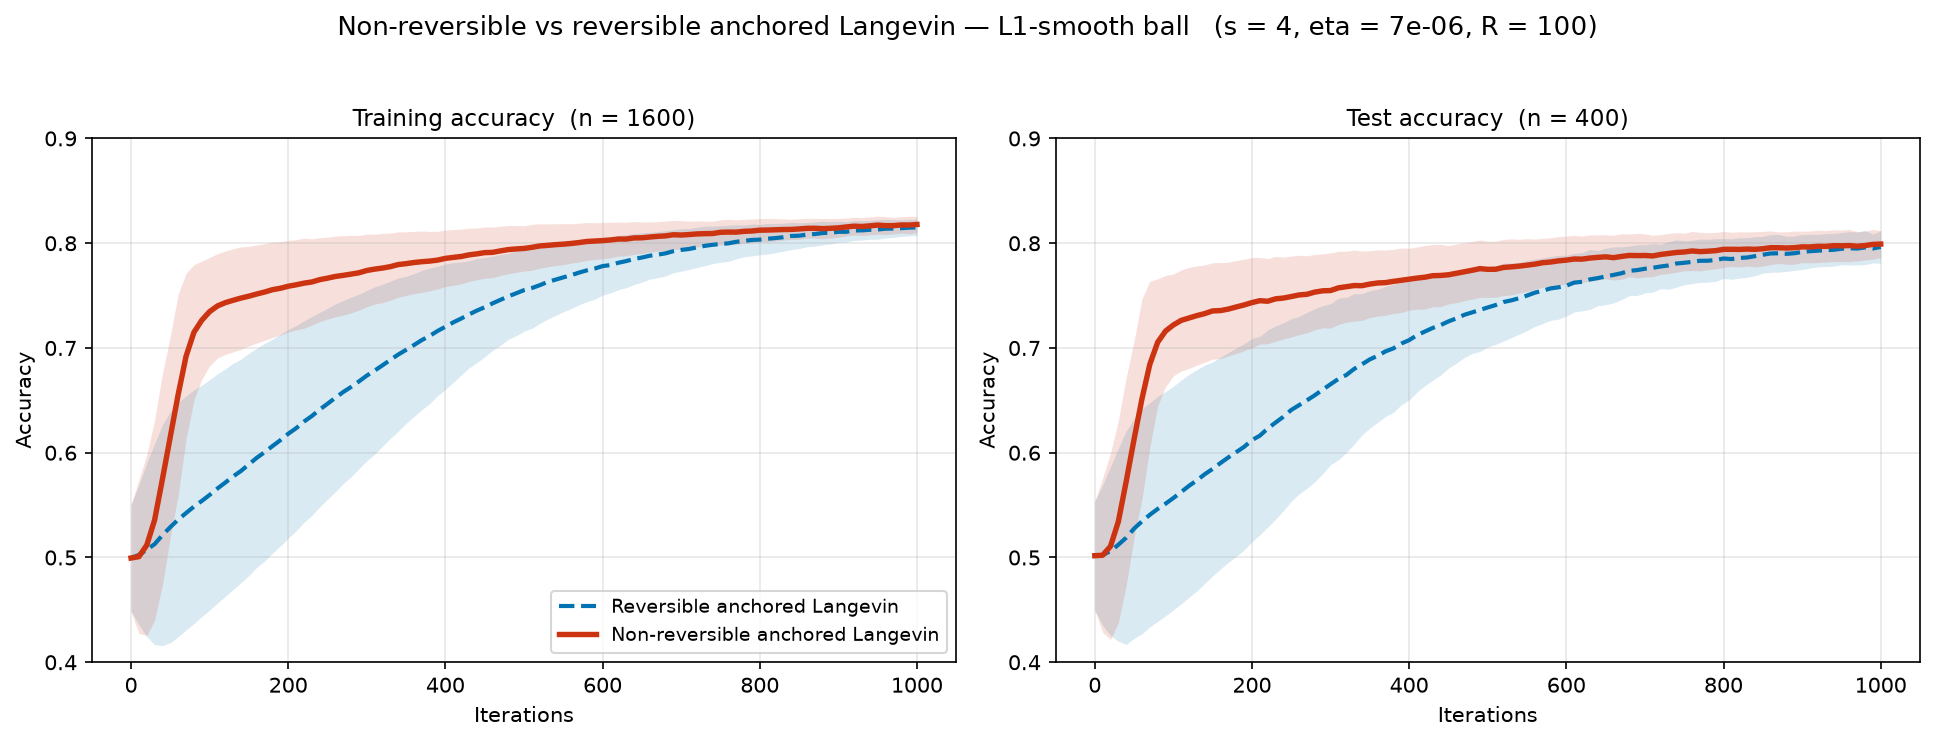

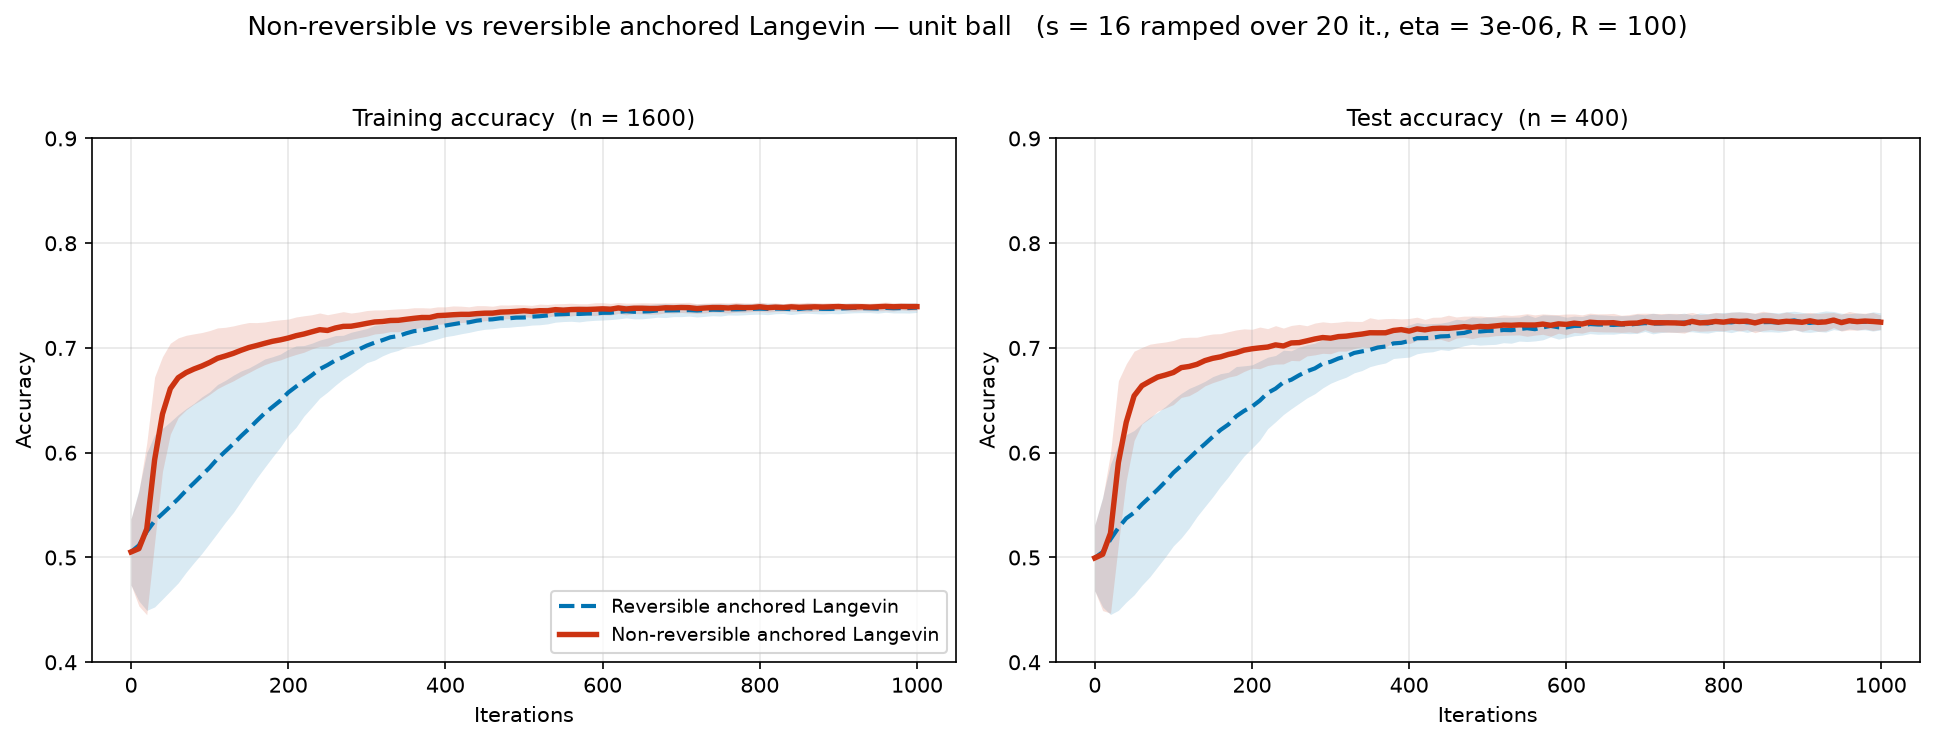

In [9]:
STYLE = {"Reversible anchored Langevin":     {"color": "#0173B2", "ls": "--", "lw": 2.0},
         "Non-reversible anchored Langevin": {"color": "#CC3311", "ls": "-",  "lw": 2.6}}
for tag in ("l1", "ball"):
    geom, D, p = GEOMETRY[tag], DATA[tag], SETTINGS[tag]
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
    for ax, which, title in ((axes[0], "train", f"Training accuracy  (n = {len(D['y_train'])})"),
                             (axes[1], "test",  f"Test accuracy  (n = {len(D['y_test'])})")):
        for name, run in results[tag].items():
            st = STYLE[name]; mean, sd = run[which].mean(axis=1), run[which].std(axis=1, ddof=1)
            ax.fill_between(run["checkpoints"], np.clip(mean - sd, 0, 1), np.clip(mean + sd, 0, 1), color=st["color"], alpha=0.15, lw=0)
            ax.plot(run["checkpoints"], mean, color=st["color"], ls=st["ls"], lw=st["lw"], label=name)
        ax.set_ylim(0.40, 0.90); ax.set_xlabel("Iterations"); ax.set_ylabel("Accuracy"); ax.set_title(title, fontsize=11); ax.grid(alpha=0.3)
    axes[0].legend(fontsize=9, loc="lower right")
    fig.suptitle(f"Non-reversible vs reversible anchored Langevin — {geom.name}   (s = {p['s']:g}"
                 + (f" ramped over {p['s_warmup']} it." if p.get("s_warmup") else "") + f", eta = {p['eta']:.0e}, R = {R})", fontsize=12.5)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    png = os.path.join(OUT, f"simple_accuracy_{tag}.png"); fig.savefig(png, dpi=150, bbox_inches="tight"); plt.close(fig)
    display(Image(filename=png))

## 8. The numbers

Paired per-replicate differences (non-reversible minus reversible) of single-iterate test
accuracy, with the paired $t$-statistic over the $R$ replicates. Then the whole comparison is
repeated on four sampler seeds that took no part in choosing the configuration, evaluated at
the iteration where the gap peaked in the search run (100 on the $L_1$ ball, 60 on the unit
ball; these were fixed before the held-out seeds were drawn, and the peak of the run above is
printed next to them). The verdict is `CONFIRMED` when every held-out seed gives a positive
paired difference **and** the pooled paired $t$ (differences averaged over seeds, standard
errors combined in quadrature) exceeds 2; otherwise `NOT confirmed`.

In [10]:
def paired(nr, rev):
    d = nr - rev; se = d.std(ddof=1) / np.sqrt(len(d))
    return d.mean(), se, d.mean() / se if se > 0 else np.nan

rows = []
for tag in ("l1", "ball"):
    rev, nr = results[tag]["Reversible anchored Langevin"], results[tag]["Non-reversible anchored Langevin"]
    for k in [k for k in (50, 100, 200, 300, 400, 600, 800) if k < N_ITERATIONS] + [N_ITERATIONS]:
        i = int(np.argmin(np.abs(rev["checkpoints"] - k)))
        m, se, t = paired(nr["test"][i], rev["test"][i])
        rows.append({"geometry": GEOMETRY[tag].name, "iteration": int(rev["checkpoints"][i]), "reversible": rev["test"][i].mean(),
                     "non_reversible": nr["test"][i].mean(), "paired_diff": m, "paired_se": se, "t_stat": t})
display(pd.DataFrame(rows))

EVALUATE_AT = {"l1": 100, "ball": 60}          # fixed from the search run, before the held-out seeds were drawn
for tag in ("l1", "ball"):
    rev, nr = results[tag]["Reversible anchored Langevin"], results[tag]["Non-reversible anchored Langevin"]
    gap = nr["test"].mean(axis=1) - rev["test"].mean(axis=1)
    print(f"{GEOMETRY[tag].name:<16} peak mean gap {gap.max():+.4f} at iteration {int(rev['checkpoints'][np.argmax(gap)])}; "
          f"held-out evaluation at iteration {EVALUATE_AT[tag]}")
held = []
for tag in ("l1", "ball"):
    diffs, ses = [], []
    for off in HELD_OUT:
        streams = shared_streams(GEOMETRY[tag], seed_offset=off)
        rev = run_chain(0.0, DATA[tag], GEOMETRY[tag], streams=streams, **SETTINGS[tag])
        nr  = run_chain(1.0, DATA[tag], GEOMETRY[tag], streams=streams, **SETTINGS[tag])
        i = int(np.argmin(np.abs(rev["checkpoints"] - EVALUATE_AT[tag])))
        m, se, t = paired(nr["test"][i], rev["test"][i]); diffs.append(m); ses.append(se)
        held.append({"geometry": GEOMETRY[tag].name, "seed_offset": off, "iteration": int(rev["checkpoints"][i]),
                     "reversible": rev["test"][i].mean(), "non_reversible": nr["test"][i].mean(), "paired_diff": m, "t_stat": t})
    pooled, pooled_se = np.mean(diffs), np.sqrt(np.sum(np.square(ses))) / len(ses)
    print(f"{GEOMETRY[tag].name:<16} held-out pooled diff {pooled:+.4f} at iteration {EVALUATE_AT[tag]} (t = {pooled / pooled_se:+.1f}), "
          f"all seeds positive: {all(d > 0 for d in diffs)}  ->  {'CONFIRMED' if all(d > 0 for d in diffs) and pooled / pooled_se > 2 else 'NOT confirmed'}")
display(pd.DataFrame(held))

,geometry,iteration,reversible,non_reversible,paired_diff,paired_se,t_stat
0,L1-smooth ball,50,0.5276,0.6130,0.0854,0.0135,6.3095
1,L1-smooth ball,100,0.5568,0.7220,0.1652,0.0111,14.8250
2,L1-smooth ball,200,0.6120,0.7433,0.1313,0.0099,13.2196
3,L1-smooth ball,300,0.6654,0.7548,0.0895,0.0077,11.6920
4,L1-smooth ball,400,0.7075,0.7657,0.0582,0.0056,10.3972
5,L1-smooth ball,600,0.7594,0.7839,0.0244,0.0030,8.1156
6,L1-smooth ball,800,0.7854,0.7942,0.0088,0.0022,3.9777
7,L1-smooth ball,1000,0.7964,0.7992,0.0028,0.0018,1.5367
8,unit ball,50,0.5428,0.6543,0.1115,0.0086,13.0403
9,unit ball,100,0.5810,0.6766,0.0956,0.0073,13.1358


L1-smooth ball   peak mean gap +0.1652 at iteration 100; held-out evaluation at iteration 100
unit ball        peak mean gap +0.1132 at iteration 60; held-out evaluation at iteration 60


L1-smooth ball   held-out pooled diff +0.1639 at iteration 100 (t = +29.1), all seeds positive: True  ->  CONFIRMED


unit ball        held-out pooled diff +0.1235 at iteration 60 (t = +27.0), all seeds positive: True  ->  CONFIRMED


,geometry,seed_offset,iteration,reversible,non_reversible,paired_diff,t_stat
0,L1-smooth ball,101,100,0.5579,0.7070,0.1490,14.4237
1,L1-smooth ball,202,100,0.5492,0.7189,0.1697,13.6940
2,L1-smooth ball,303,100,0.5501,0.7107,0.1606,15.0242
3,L1-smooth ball,404,100,0.5307,0.7071,0.1764,15.2466
4,unit ball,101,60,0.5387,0.6670,0.1283,13.1951
5,unit ball,202,60,0.5453,0.6675,0.1222,15.0379
6,unit ball,303,60,0.5438,0.6612,0.1174,13.2024
7,unit ball,404,60,0.5423,0.6684,0.1262,12.9706


## 9. Why the non-reversible chain is faster here — and where it is not

**Linearise at the mode.** Near the posterior mode $w^*$ the drift is $-\eta a(I-\alpha J)H$
with $H=\nabla^2U_0(w^*)$. Inside one triple $I$, $J_I=[v_I]_\times$ rotates only in the plane
**perpendicular** to its axis $v_I$. Let $\lambda_{\rm fast}\ge\lambda_{\rm slow}$ be the
curvatures of the two directions in that plane (in the $L_1$ design $\approx14{,}000$ along
$q_2$ and $\approx340$ along $q_3$ at the mode; the axis direction $q_1$ has its own curvature,
$\approx160$, and is untouched by $J$ — it is the same for both chains).

* In the plane the two rates become
  $\tfrac{\lambda_{\rm fast}+\lambda_{\rm slow}}{2}\pm\sqrt{\tfrac{(\lambda_{\rm fast}-\lambda_{\rm slow})^2}{4}-\sigma^2\lambda_{\rm fast}\lambda_{\rm slow}}$
  with $\sigma=|v_I|$ ($=s\|w_I\|$ on the ball, $=s\,\|w_I/\sqrt{w_I^2+\varepsilon^2}\|\approx s\sqrt3$ on the
  $L_1$ ball once $|w_i|\gg\varepsilon$). For
  $\sigma\ge\sigma^*=\tfrac{\lambda_{\rm fast}-\lambda_{\rm slow}}{2\sqrt{\lambda_{\rm fast}\lambda_{\rm slow}}}$
  the slow rate is replaced by the mean $\tfrac{\lambda_{\rm fast}+\lambda_{\rm slow}}{2}$: a
  speed-up of $(\kappa+1)/2$ with $\kappa=\lambda_{\rm fast}/\lambda_{\rm slow}$ ($\approx40$ here, so
  $\approx20\times$). In discrete time the pair stays stable while
  $\sigma^2<\tfrac{\lambda_{\rm fast}+\lambda_{\rm slow}}{\eta a\lambda_{\rm fast}\lambda_{\rm slow}}-1$
  — at the mode of the $L_1$ design that is $s\lesssim14$ for $\eta=7\cdot10^{-6}$, which is where
  the parameter map shows the projection starting to pin the chain.
* A slow direction **along** the axis is untouched for every $s$; one at angle $\theta$ to the
  rotated plane gains roughly at most $1/\cos^2\theta$ (a heuristic, not a bound).
* On the ball the axis at the mode is $w^*_I$ itself, so the ball can never accelerate the
  direction of the block's dominant coefficient. Under the $L_1$ geometry the axis is the
  soft-sign of $w_I$, $\approx(1,1,1)/\sqrt3$, so $q_3=(2,-1,-1)/\sqrt6$ is in the plane **and**
  carries signal ($q_3\cdot\beta_I\ne0$). On the ball the axis at the mode is $\propto(b,e,e)=(4,1,1)$,
  so $q_3$ is oblique to the rotated plane ($\cos\theta\approx0.8$) and the linearised gain is
  smaller; the observed ball gap is nevertheless large because the transient in the figures
  starts from a uniform draw on $K$, far from the mode, where the axis $s\,w_I$ points in a
  random direction and the rotation acts on the whole residual.

**Why it shows in accuracy.** A residual $\Delta$ along a direction with feature variance
$v$ perturbs the test logits by $\sqrt v\,|\Delta|$, and the accuracy loss is
$\approx\rho(0)\,\tau^2/4$ for a logit perturbation of standard deviation $\tau$, where $\rho$ is
the density of the true logits at $0$. The residual along $q_3$ carries an $O(1)$ share of the
logit variance, so while the reversible chain still has it, its accuracy is visibly lower.

**Where the win lives** (one factor at a time around the $L_1$ configuration,
`results_beat/parameter_map.md`; the $s$ window below is for the $L_1$ geometry — on the ball
the same $s$ is a much smaller rotation, see section 6): anisotropy $\kappa=v_{\rm fast}/v_{\rm slow}\ge4$
(the gap grows with $\kappa$ and saturates near $\kappa\approx32$), $0.5\le s\le12$,
$2\cdot10^{-6}\le\eta\le6\cdot10^{-5}$, any $\lambda_{\rm lasso}$, $\delta$, $n$, $\varepsilon$ and radius
tried. **Ties:** $\kappa=1$ (only a marginal $+0.02$ at $\kappa=2$), $s=0$, an isotropic design, a
signal-free slow direction, initialisation at the origin, and any iteration after both chains
have converged. **Late deficit:** $s\ge16$ or $\eta=10^{-4}$ — past the stability edge the rotation
overshoots and the projection fires on 33% / 61% of the steps; the non-reversible chain still
wins the transient by $\approx0.2$ but ends $0.007$–$0.009$ below the reversible one.

**Scope.** This is a convergence-speed effect on a designed regime (strongly unequal
feature scales with the signal in a low-variance direction that lies in the rotated
plane). Both chains reach the same plateau; the effect is the transient between a uniform
start on $K$ and that plateau.